In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import csv
import cv2
import os
from keras.applications.resnet import preprocess_input
from keras.utils import Sequence

In [2]:
with open('datasets/anno_train.csv','r') as my_file:
    reader = csv.reader(my_file,delimiter='\t')
    train_list = list(reader)
#     print(train_list)
    


In [3]:
with open('datasets/anno_test.csv','r') as my_file:
    reader = csv.reader(my_file,delimiter='\t')
    test_list = list(reader)
#     print(test_list)

In [4]:
with open('datasets/names.csv','r') as my_file:
    reader = csv.reader(my_file , delimiter=',')
    class_names = list(reader)
    num_classes = len(class_names)
#     print(class_names)
    

In [5]:
train_folder = 'datasets/car_data/car_data/train'
test_folder = 'datasets/car_data/car_data/test'


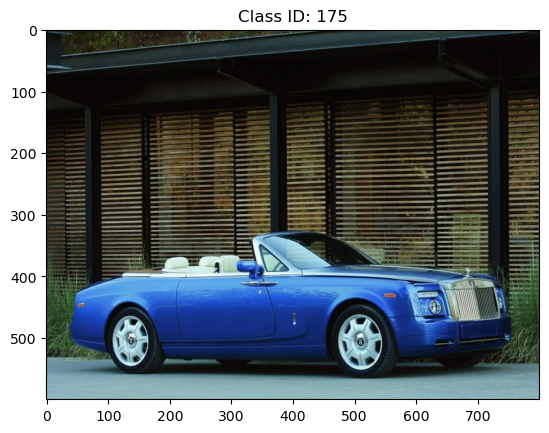

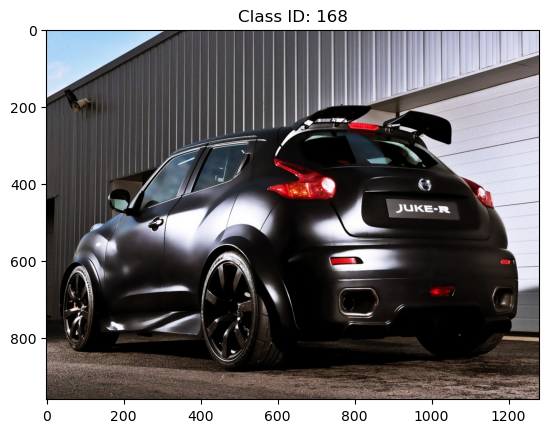

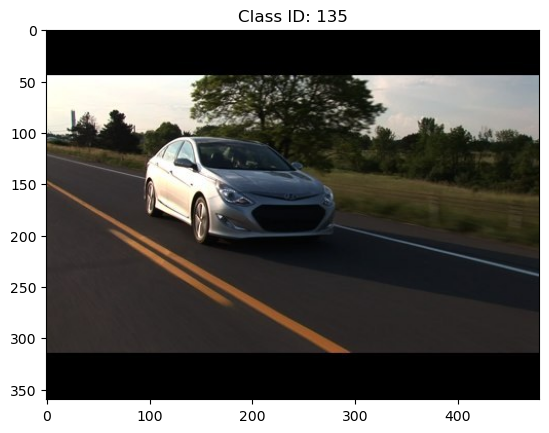

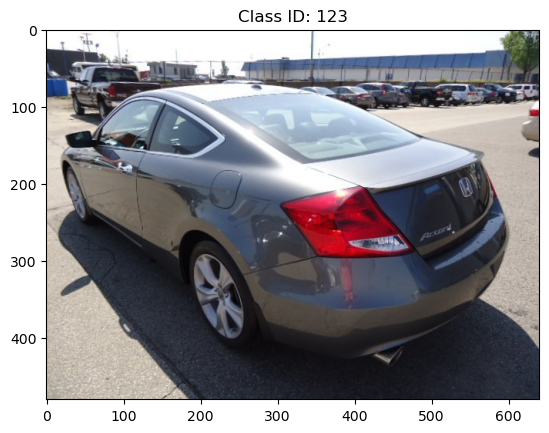

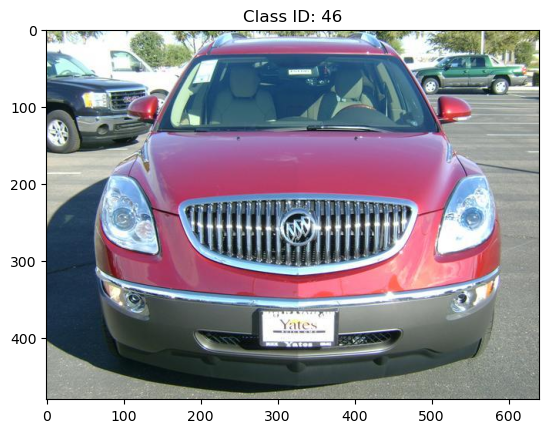

In [6]:
# List all subdirectories (each subdirectory represents a class)
class_folders = [os.path.join(train_folder, d) for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]

# Function to list all image files in a directory
def list_image_files(directory):
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.lower().endswith('.jpg')]

# List of all image files along with their corresponding class labels
image_files = []
class_labels = []

# Iterate through each class folder
for class_id, class_folder in enumerate(class_folders):
    # List all image files in the class folder
    class_images = list_image_files(class_folder)
    
    # Append image files and their corresponding class labels
    image_files.extend(class_images)
    class_labels.extend([class_id] * len(class_images))

# Shuffle the dataset
dataset = list(zip(image_files, class_labels))
np.random.shuffle(dataset)

# Visualize random images with their corresponding labels
for i in range(5):
    image_path, class_id = dataset[i]
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.figure()
    plt.imshow(image_rgb)
    plt.title(f"Class ID: {class_id}")


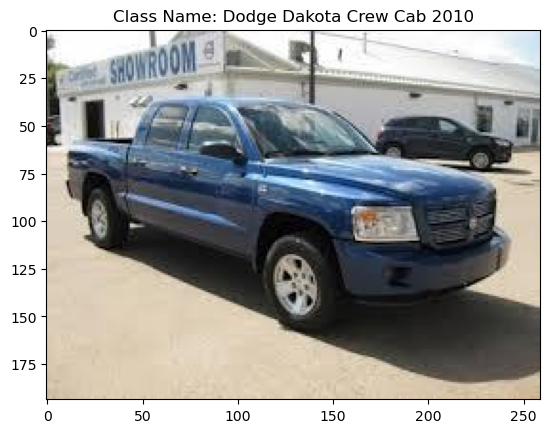

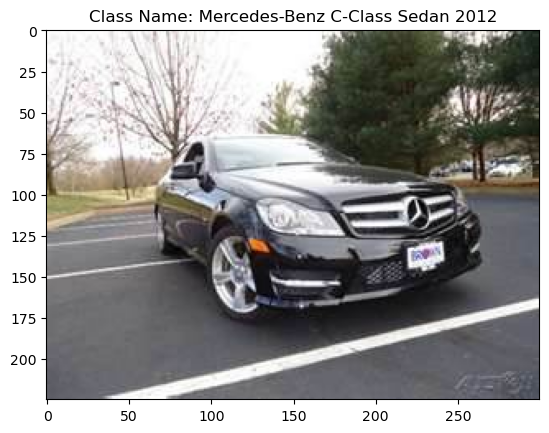

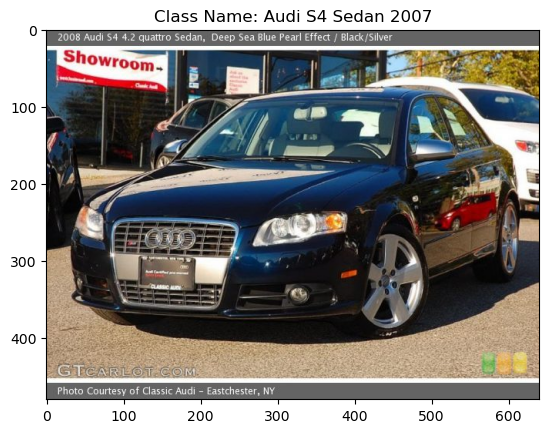

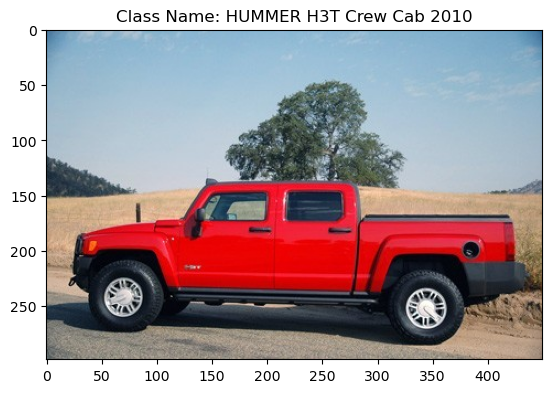

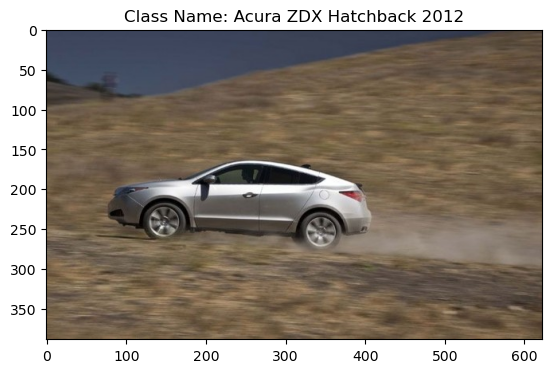

In [7]:

# List all subdirectories (each subdirectory represents a class)
class_folders = [os.path.join(train_folder, d) for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]

# Function to list all image files in a directory
def list_image_files(directory):
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.lower().endswith('.jpg')]

# List of all image files along with their corresponding class names
image_files = []
class_names = []

# Iterate through each class folder
for class_folder in class_folders:
    # Extract class name from folder name
    class_name = os.path.basename(class_folder)
    
    # List all image files in the class folder
    class_images = list_image_files(class_folder)
    
    # Append image files and their corresponding class names
    image_files.extend(class_images)
    class_names.extend([class_name] * len(class_images))

# Shuffle the dataset
dataset = list(zip(image_files, class_names))
np.random.shuffle(dataset)

# Visualize random images with their corresponding class names
for i in range(5):
    image_path, class_name = dataset[i]
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.figure()
    plt.imshow(image_rgb)
    plt.title(f"Class Name: {class_name}")
    

    


In [8]:
model = keras.applications.ResNet50(input_shape=(224,224,3),classes=196,weights=None)
model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 56, 56, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 56, 56, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                  'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block1_add[0][0]']       
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 7, 7, 512)    1049088     ['conv5_block1_out[0][0]']       
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

### 2:02:30 

In [9]:

class DataGenerator(Sequence):
    def __init__(self, dataset, class_dict, batch_size=32, dim=(224, 224), n_channels=3, shuffle=True):
        self.dataset = dataset
        self.class_dict = class_dict
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataset))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataset) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X, y = self.__data_generation(indexes)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, indexes):
        X = np.empty((len(indexes), *self.dim, self.n_channels))
        y = np.empty((len(indexes)), dtype=int)

        for i, ind in enumerate(indexes):
            class_folder, image_name = self.dataset[ind]
            class_id = self.class_dict[class_folder]  # Retrieve class ID from class dictionary
            image_path = os.path.join(class_folder, image_name)
            image = cv2.imread(image_path)
            image = cv2.resize(image, self.dim)
            image = preprocess_input(image)
            X[i,] = image
            y[i] = class_id

        return X, keras.utils.to_categorical(y, num_classes=len(self.class_dict))


class_folders_train = [os.path.join(train_folder, d) for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]

# Create a dictionary to map class folder names to class IDs for train data
class_dict_train = {class_folder: i for i, class_folder in enumerate(class_folders_train)}

# List of all image files along with their corresponding class labels for train data
dataset_train = []
for class_folder in class_folders_train:
    for image_name in os.listdir(class_folder):
        dataset_train.append((class_folder, image_name))

# List all subdirectories (each subdirectory represents a class) in the test folder
class_folders_test = [os.path.join(test_folder, d) for d in os.listdir(test_folder) if os.path.isdir(os.path.join(test_folder, d))]

# Create a dictionary to map class folder names to class IDs for test data
class_dict_test = {class_folder: i for i, class_folder in enumerate(class_folders_test)}

# List of all image files along with their corresponding class labels for test data
dataset_test = []
for class_folder in class_folders_test:
    for image_name in os.listdir(class_folder):
        dataset_test.append((class_folder, image_name))

# Define parameters for the data generator
batch_size = 32
image_dim = (224, 224)
num_channels = 3

# Create train and test data generators
train_generator = DataGenerator(dataset_train, class_dict_train, batch_size=batch_size, dim=image_dim,
                                n_channels=num_channels)
test_generator = DataGenerator(dataset_test, class_dict_test, batch_size=batch_size, dim=image_dim,
                               n_channels=num_channels)




In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_generator, epochs=10, validation_data=test_generator)

# Evaluate the model
# model.evaluate(test_generator)


Epoch 1/10
255/255 [==============================] - 632s 2s/step - loss: 5.6564 - accuracy: 0.0055 - val_loss: 5.6507 - val_accuracy: 0.0070
Epoch 2/10
255/255 [==============================] - 603s 2s/step - loss: 5.3081 - accuracy: 0.0076 - val_loss: 5.9659 - val_accuracy: 0.0093
Epoch 3/10
255/255 [==============================] - 603s 2s/step - loss: 5.2402 - accuracy: 0.0109 - val_loss: 5.1938 - val_accuracy: 0.0116
Epoch 4/10
255/255 [==============================] - 603s 2s/step - loss: 5.1893 - accuracy: 0.0128 - val_loss: 7.8593 - val_accuracy: 0.0085
Epoch 5/10
255/255 [==============================] - 601s 2s/step - loss: 5.1533 - accuracy: 0.0102 - val_loss: 5.2356 - val_accuracy: 0.0139
Epoch 6/10
255/255 [==============================] - 603s 2s/step - loss: 5.1155 - accuracy: 0.0169 - val_loss: 5.1688 - val_accuracy: 0.0147
Epoch 7/10
255/255 [==============================] - 603s 2s/step - loss: 5.0267 - accuracy: 0.0223 - val_loss: 5.4034 - val_accuracy: 0.0153

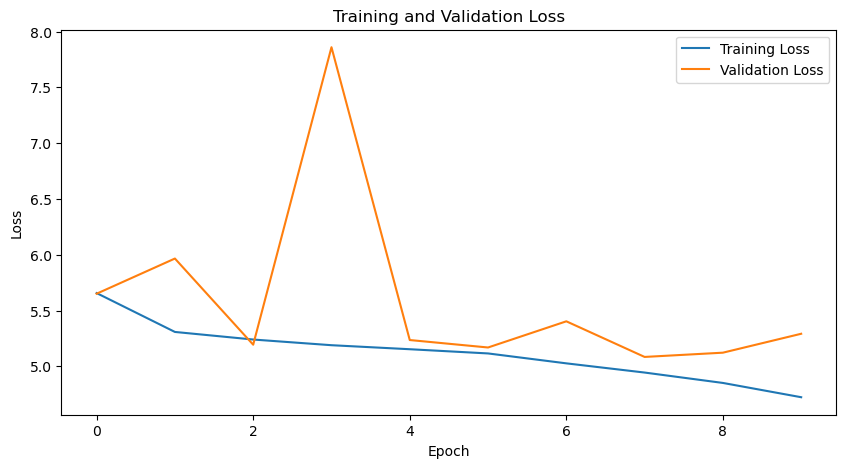

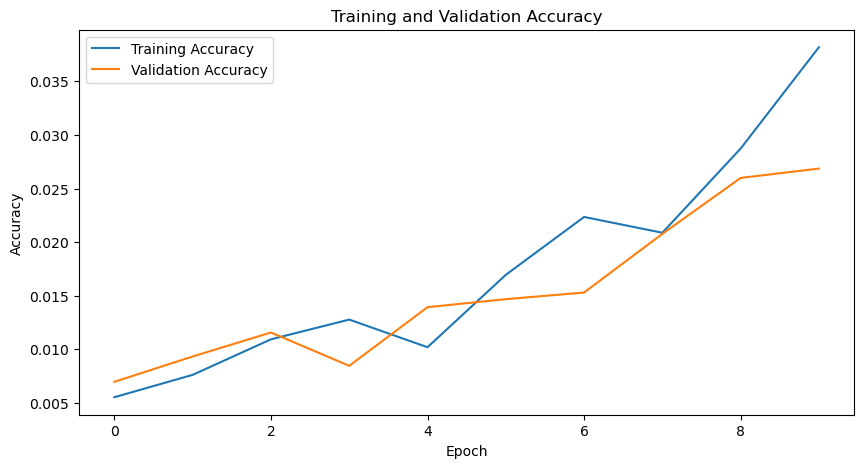

In [12]:

history = model.history.history

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### transfer learning

In [8]:

class DataGenerator(Sequence):
    def __init__(self, dataset, class_dict, batch_size=32, dim=(224, 224), n_channels=3, shuffle=True):
        self.dataset = dataset
        self.class_dict = class_dict
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataset))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataset) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X, y = self.__data_generation(indexes)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, indexes):
        X = np.empty((len(indexes), *self.dim, self.n_channels))
        y = np.empty((len(indexes)), dtype=int)

        for i, ind in enumerate(indexes):
            class_folder, image_name = self.dataset[ind]
            class_id = self.class_dict[class_folder]  # Retrieve class ID from class dictionary
            image_path = os.path.join(class_folder, image_name)
            image = cv2.imread(image_path)
            image = cv2.resize(image, self.dim)
            image = preprocess_input(image)
            X[i,] = image
            y[i] = class_id

        return X, keras.utils.to_categorical(y, num_classes=len(self.class_dict))


class_folders_train = [os.path.join(train_folder, d) for d in os.listdir(train_folder) if os.path.isdir(os.path.join(train_folder, d))]

# Create a dictionary to map class folder names to class IDs for train data
class_dict_train = {class_folder: i for i, class_folder in enumerate(class_folders_train)}

# List of all image files along with their corresponding class labels for train data
dataset_train = []
for class_folder in class_folders_train:
    for image_name in os.listdir(class_folder):
        dataset_train.append((class_folder, image_name))

# List all subdirectories (each subdirectory represents a class) in the test folder
class_folders_test = [os.path.join(test_folder, d) for d in os.listdir(test_folder) if os.path.isdir(os.path.join(test_folder, d))]

# Create a dictionary to map class folder names to class IDs for test data
class_dict_test = {class_folder: i for i, class_folder in enumerate(class_folders_test)}

# List of all image files along with their corresponding class labels for test data
dataset_test = []
for class_folder in class_folders_test:
    for image_name in os.listdir(class_folder):
        dataset_test.append((class_folder, image_name))

# Define parameters for the data generator
batch_size = 32
image_dim = (224, 224)
num_channels = 3

# Create train and test data generators
train_generator = DataGenerator(dataset_train, class_dict_train, batch_size=batch_size, dim=image_dim,
                                n_channels=num_channels)
test_generator = DataGenerator(dataset_test, class_dict_test, batch_size=batch_size, dim=image_dim,
                               n_channels=num_channels)




In [9]:
model = keras.applications.ResNet50(input_shape=(224, 224, 3), classes=196, weights='imagenet', include_top=False, pooling='avg')
x = keras.layers.Dense(units=196, activation='softmax')(model.output)
model = keras.models.Model(model.input, x)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                              

                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_2_conv (Conv2D)   (None, 56, 56, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 56, 56, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 56, 56, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                  'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block1_add[0][0]']       
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 7, 7, 512)    1049088     ['conv5_block1_out[0][0]']       
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

In [12]:
model.compile(loss='categorical_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              metrics='accuracy')

# Train model on dataset
history = model.fit(train_generator,
                    validation_data=test_generator,
                    epochs=10,
                    shuffle=False)

Epoch 1/10
255/255 [==============================] - 172s 655ms/step - loss: 4.2509 - accuracy: 0.0684 - val_loss: 4.7598 - val_accuracy: 0.0576
Epoch 2/10
255/255 [==============================] - 172s 676ms/step - loss: 3.5625 - accuracy: 0.1390 - val_loss: 3.6974 - val_accuracy: 0.1378
Epoch 3/10
255/255 [==============================] - 187s 733ms/step - loss: 2.7215 - accuracy: 0.2898 - val_loss: 3.0108 - val_accuracy: 0.2559
Epoch 4/10
255/255 [==============================] - 165s 649ms/step - loss: 1.8768 - accuracy: 0.4835 - val_loss: 3.3366 - val_accuracy: 0.2343
Epoch 5/10
255/255 [==============================] - 168s 659ms/step - loss: 1.1980 - accuracy: 0.6627 - val_loss: 3.0001 - val_accuracy: 0.2971
Epoch 6/10
255/255 [==============================] - 188s 738ms/step - loss: 0.6823 - accuracy: 0.8043 - val_loss: 2.9291 - val_accuracy: 0.3613
Epoch 7/10
255/255 [==============================] - 168s 660ms/step - loss: 0.3719 - accuracy: 0.8962 - val_loss: 3.7265 -

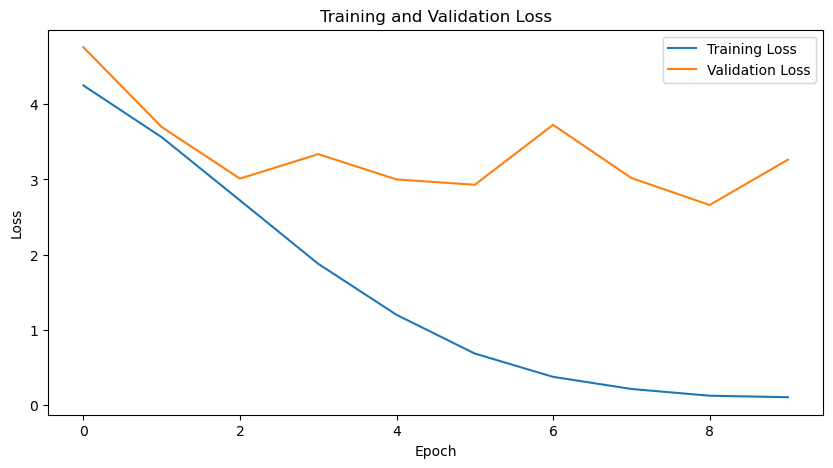

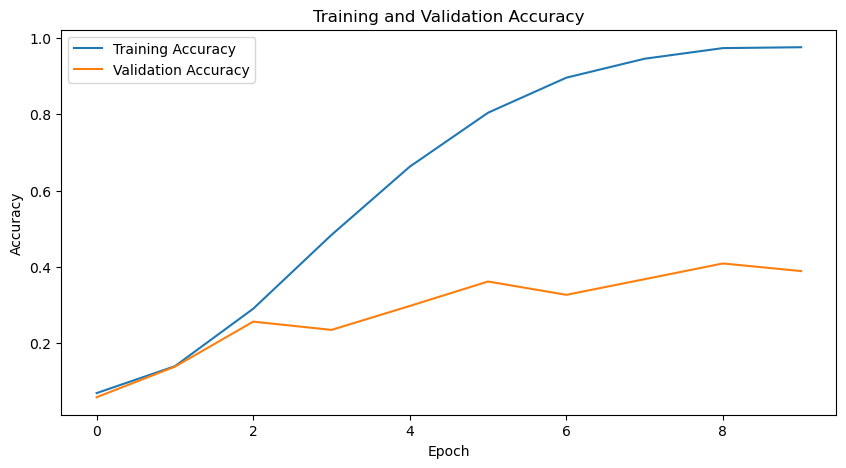

In [13]:

history = model.history.history

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### 3:00:00